# Menyatukan Data Seluruh Review

In [2]:
#importing needed library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#load seluruh file dan masukan penanda column cafe sebagai penanda bahwa review tersebut dari cabang tertentu
#alamat akan digunakan sebagai penanda cafe
file = 'samarinda-tomorow-rev-overnight.xlsx'
sheet1 = pd.read_excel(file, 
                        sheet_name = 0)
#memberikan penanda dari mana data review tersebut pada setiap sheet (ini sesuai dengan urutan dari sheet di excell yang ada)
sheet1["cafe"] = "PM Noor Samarinda"

sheet2 = pd.read_excel(file, 
                        sheet_name = 1)
sheet2["cafe"] = "M Yamin"

sheet3 = pd.read_excel(file, 
                        sheet_name = 2)
sheet3["cafe"] = "Sebatik"

sheet4 = pd.read_excel(file, 
                        sheet_name = 3)
sheet4["cafe"] = "Merak Square"

sheet5 = pd.read_excel(file, 
                        sheet_name = 4)
sheet5["cafe"] = "Bung Tomo"

#menyatukan each sheet di excell
newData = pd.concat([sheet1, sheet2, sheet3, sheet4, sheet5], ignore_index=True)

In [4]:
newData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   nama_reviewer               1558 non-null   object 
 1   rating                      1558 non-null   int64  
 2   waktu_relatif               1558 non-null   object 
 3   review                      902 non-null    object 
 4   Makanan                     873 non-null    float64
 5   Layanan                     1185 non-null   float64
 6   Suasana                     1164 non-null   float64
 7   Tarif per orang             366 non-null    object 
 8   Tingkat kebisingan          179 non-null    object 
 9   Waktu tunggu                160 non-null    object 
 10  Jenis pesanan               250 non-null    object 
 11  Jenis makanan               186 non-null    object 
 12  Tempat parkir               73 non-null     object 
 13  Opsi tempat parkir          63 no

# Membersihkan data seluruh review

In [6]:
df = newData.copy()

### nama_reviewer

In [8]:
nama = df[['nama_reviewer']]

In [9]:
nama.shape

(1558, 1)

In [10]:
nama.nunique()

nama_reviewer    1471
dtype: int64

In [11]:
1558 - 1471

87

In [12]:
nama.isnull().sum()

nama_reviewer    0
dtype: int64

In [13]:
nama.dtypes

nama_reviewer    object
dtype: object

### rating

In [15]:
rating = df[['rating']]

In [16]:
rating.shape

(1558, 1)

In [17]:
#apakah ada yang NaN
rating.isnull().sum()

rating    0
dtype: int64

In [18]:
#check keseluruhan unique value
rating['rating'].unique()

array([5, 1, 4, 2, 3], dtype=int64)

In [19]:
#check berapa banyak tiap rating di dalam df
rating['rating'].value_counts()

rating
5    1319
4      99
1      76
3      38
2      26
Name: count, dtype: int64

In [20]:
#percentage jumlah rating dari seluruh data yang ada di rounding 2 desimal
round((rating['rating'].value_counts(normalize=True) * 100),2)

rating
5    84.66
4     6.35
1     4.88
3     2.44
2     1.67
Name: proportion, dtype: float64

In [21]:
#general statistics
rating.describe()

,rating
count,1558.000000
mean,4.642490
std,0.982136
min,1.000000
25%,5.000000
50%,5.000000
75%,5.000000
max,5.000000


In [22]:
#median, mean, standard deviasi rating
rating['rating'].agg(['median','mean', 'std'])

median    5.000000
mean      4.642490
std       0.982136
Name: rating, dtype: float64

In [23]:
#modus rating
rating['rating'].mode()

0    5
Name: rating, dtype: int64

In [24]:
#mengkategorikan rating 4-5 sebagai puas, 1-2 sebagai tidak puas, dan 3 sebagai netral 
filt = ((rating['rating'] == 4) | (rating['rating'] == 5))
filt_non = ((rating['rating'] == 1) | (rating['rating'] == 2))
filt_net = ((rating['rating'] == 3))
rating.loc[filt, 'Kepuasan'] = 'Puas'
rating.loc[filt_non, 'Kepuasan'] = 'Tidak Puas'
rating.loc[filt_net, 'Kepuasan'] = 'Netral'

C:\Users\Bocah\AppData\Local\Temp\ipykernel_21004\3305201011.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rating.loc[filt, 'Kepuasan'] = 'Puas'


In [25]:
rating

,rating,Kepuasan
0,5,Puas
1,5,Puas
2,1,Tidak Puas
3,4,Puas
4,5,Puas
...,...,...
1553,5,Puas
1554,5,Puas
1555,5,Puas
1556,5,Puas


In [26]:
rating['Kepuasan'].value_counts()

Kepuasan
Puas          1418
Tidak Puas     102
Netral          38
Name: count, dtype: int64

In [27]:
round(rating['Kepuasan'].value_counts(normalize=True),2) * 100

Kepuasan
Puas          91.0
Tidak Puas     7.0
Netral         2.0
Name: proportion, dtype: float64

In [28]:
#menambahkan tingkat kepuasan pada dataframe utama
df["Tingkat Kepuasan"] = rating['Kepuasan']

### waktu_relatif

In [30]:
waktu = df[['waktu_relatif']]

In [31]:
waktu.isnull().sum()

waktu_relatif    0
dtype: int64

In [32]:
waktu['waktu_relatif'].unique()

array(['2 hari lalu', 'seminggu lalu', 'sebulan lalu', '2 bulan lalu',
       'Diedit 2 bulan lalu', '3 bulan lalu', '4 bulan lalu',
       '5 bulan lalu', '6 bulan lalu', '7 bulan lalu', '8 bulan lalu',
       '9 bulan lalu', '10 bulan lalu', '11 bulan lalu', 'setahun lalu',
       'Diedit setahun lalu', '5 hari lalu', '2 minggu lalu',
       'Diedit 2 minggu lalu', '3 minggu lalu', 'Diedit sebulan lalu',
       'Diedit 6 bulan lalu', '4 minggu lalu', 'Diedit 5 bulan lalu',
       'Diedit 10 bulan lalu', 'Diedit 9 bulan lalu', '1 hari lalu',
       'Diedit 4 hari lalu', '6 hari lalu', 'Diedit 7 bulan lalu'],
      dtype=object)

In [33]:
waktu.value_counts()

waktu_relatif       
setahun lalu            584
10 bulan lalu           226
6 bulan lalu            204
9 bulan lalu            160
sebulan lalu             71
11 bulan lalu            45
2 minggu lalu            37
5 bulan lalu             36
7 bulan lalu             34
8 bulan lalu             31
2 bulan lalu             28
4 bulan lalu             27
3 bulan lalu             24
seminggu lalu            10
Diedit setahun lalu       8
3 minggu lalu             6
Diedit sebulan lalu       6
Diedit 10 bulan lalu      5
Diedit 5 bulan lalu       3
2 hari lalu               2
5 hari lalu               2
4 minggu lalu             1
Diedit 9 bulan lalu       1
Diedit 4 hari lalu        1
Diedit 7 bulan lalu       1
Diedit 6 bulan lalu       1
Diedit 2 minggu lalu      1
Diedit 2 bulan lalu       1
6 hari lalu               1
1 hari lalu               1
Name: count, dtype: int64

In [34]:
#menampilkan berapa banyak review yang di edit
print("apakah diedit?")
(waktu['waktu_relatif'].str.contains('Diedit')).value_counts()

apakah diedit?


waktu_relatif
False    1530
True       28
Name: count, dtype: int64

In [35]:
round((waktu['waktu_relatif'].str.contains('Diedit')).value_counts(normalize=True),2) * 100

waktu_relatif
False    98.0
True      2.0
Name: proportion, dtype: float64

In [36]:
# Mengubah jadi datetime format dari text
from datetime import datetime

#hapus semua Diedit dan ubah seminggu, sebulan, setahun
#mengganti seluruh Diedit menjadi waktu biasa, ini yang nanti akan jadi waktu relatif baru
waktu['waktu_relatif'] = waktu['waktu_relatif'].str.replace("Diedit ",'') 
waktu['waktu_relatif'] = waktu['waktu_relatif'].str.replace("seminggu ",'1 minggu ') 
waktu['waktu_relatif'] = waktu['waktu_relatif'].str.replace("sebulan ",'1 bulan ') 
waktu['waktu_relatif'] = waktu['waktu_relatif'].str.replace("setahun ",'1 tahun ')

#mengubah kolom 
tanggal_acuan = pd.to_datetime('2026-06-26')
daftar_manual = {
    '1 hari lalu': tanggal_acuan - pd.DateOffset(days=1),
    '2 hari lalu': tanggal_acuan - pd.DateOffset(days=2),
    '4 hari lalu': tanggal_acuan - pd.DateOffset(days=4),
    '5 hari lalu': tanggal_acuan - pd.DateOffset(days=5),
    '6 hari lalu': tanggal_acuan - pd.DateOffset(days=6),
    
    '1 minggu lalu': tanggal_acuan - pd.DateOffset(weeks=1),
    '2 minggu lalu': tanggal_acuan - pd.DateOffset(weeks=2),
    '3 minggu lalu': tanggal_acuan - pd.DateOffset(weeks=3),
    '4 minggu lalu': tanggal_acuan - pd.DateOffset(weeks=4),
    
    '1 bulan lalu': tanggal_acuan - pd.DateOffset(months=1),
    '2 bulan lalu': tanggal_acuan - pd.DateOffset(months=2),
    '3 bulan lalu': tanggal_acuan - pd.DateOffset(months=3),
    '4 bulan lalu': tanggal_acuan - pd.DateOffset(months=4),
    '5 bulan lalu': tanggal_acuan - pd.DateOffset(months=5),
    '6 bulan lalu': tanggal_acuan - pd.DateOffset(months=6),
    '7 bulan lalu': tanggal_acuan - pd.DateOffset(months=7),
    '8 bulan lalu': tanggal_acuan - pd.DateOffset(months=8),
    '9 bulan lalu': tanggal_acuan - pd.DateOffset(months=9),
    '10 bulan lalu': tanggal_acuan - pd.DateOffset(months=10),
    '11 bulan lalu': tanggal_acuan - pd.DateOffset(months=11),
    
    '1 tahun lalu': tanggal_acuan - pd.DateOffset(years=1)
}

# 3. Bikin kolom baru secara permanen dengan mencocokkan kolom lama ke daftar di atas
waktu['tanggal_pasti'] = waktu['waktu_relatif'].map(daftar_manual)

# 4. Pastikan format kolom barunya bertipe tanggal murni
waktu['tanggal_pasti'] = pd.to_datetime(waktu['tanggal_pasti'])


C:\Users\Bocah\AppData\Local\Temp\ipykernel_21004\1172883464.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  waktu['waktu_relatif'] = waktu['waktu_relatif'].str.replace("Diedit ",'')
C:\Users\Bocah\AppData\Local\Temp\ipykernel_21004\1172883464.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  waktu['waktu_relatif'] = waktu['waktu_relatif'].str.replace("seminggu ",'1 minggu ')
C:\Users\Bocah\AppData\Local\Temp\ipykernel_21004\1172883464.py:8: SettingWithCopyWarning: 
A value is trying to be set on a co

In [37]:
waktu.head()

,waktu_relatif,tanggal_pasti
0,2 hari lalu,2026-06-24
1,1 minggu lalu,2026-06-19
2,1 minggu lalu,2026-06-19
3,1 bulan lalu,2026-05-26
4,1 bulan lalu,2026-05-26


In [38]:
waktu['waktu_relatif'].unique()

array(['2 hari lalu', '1 minggu lalu', '1 bulan lalu', '2 bulan lalu',
       '3 bulan lalu', '4 bulan lalu', '5 bulan lalu', '6 bulan lalu',
       '7 bulan lalu', '8 bulan lalu', '9 bulan lalu', '10 bulan lalu',
       '11 bulan lalu', '1 tahun lalu', '5 hari lalu', '2 minggu lalu',
       '3 minggu lalu', '4 minggu lalu', '1 hari lalu', '4 hari lalu',
       '6 hari lalu'], dtype=object)

In [39]:
#waktu paling baru
waktu['tanggal_pasti'].max()

Timestamp('2026-06-25 00:00:00')

In [40]:
#waktu paling lama
waktu['tanggal_pasti'].min()

Timestamp('2025-06-26 00:00:00')

In [41]:
#group berdasarkan tahun
hasil = waktu.groupby(waktu['tanggal_pasti'].dt.year).count()

In [42]:
hasil

,waktu_relatif,tanggal_pasti
tanggal_pasti,,
2025,1300,1300
2026,258,258


In [43]:
#menyimpan perubahan ke dataframe
df['waktu_relatif'] = waktu['waktu_relatif'] 
df['tanggal_pasti'] = waktu['tanggal_pasti'] 

### review

In [45]:
review = df[["review"]]

In [46]:
review.head()

,review
0,Terbaiiik
1,"Makanan enak, pelayanan bagus, dan kebisingan ..."
2,"Hapus aja sistem poing member di app, percuma ..."
3,NaN
4,NaN


In [47]:
nan = review.isnull().sum()['review']  
total_data = review.shape[0]

#berapa banyak review NaN
print("total data kosong:", review['review'].isnull().sum())

#total data review
print("total data review:", total_data - nan)

#presentase nan dari total data
nan_pct = round((nan / total_data) * 100, 2)
print(f"Persentase data kosong:\n{nan_pct}%")

#presentase data exist
no_nan_pct = round((100 - nan_pct), 2) 
print(f"Persentase data kosong:\n{no_nan_pct}%")

total data kosong: 656
total data review: 902
Persentase data kosong:
42.11%
Persentase data kosong:
57.89%


In [48]:
#mengecek setiap karakter yang ada
semua_teks = "".join(review['review'].dropna())
karakter_unik = sorted(list(set(semua_teks)))
print(karakter_unik)

['\n', ' ', '!', '"', '#', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'Y', '^', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '~', '\xa0', '²', '´', 'é', 'ķ', '\u200d', '—', '“', '”', '…', '‿', '\u2060', '◡', '☕', '☝', '☺', '♀', '♡', '♥', '⚡', '✨', '✿', '❁', '❣', '❤', '⭐', '️', '￼', '🌟', '🌷', '🌿', '🍀', '🍛', '🎀', '🏻', '🏼', '🏽', '🏿', '👌', '👍', '👎', '💀', '💕', '💗', '💚', '💥', '💨', '💯', '📝', '📸', '🔥', '😁', '😂', '😃', '😅', '😆', '😇', '😉', '😊', '😋', '😍', '😎', '😘', '😙', '😬', '😭', '😮', '😲', '😻', '🙅', '🙌', '🙏', '🚮', '🤍', '🤗', '🤙', '🤝', '🤞', '🤟', '🤣', '🤤', '🤩', '🤭', '🥤', '🥰', '🥲', '🥳', '🥴', '🥹', '🥺', '🧋', '🫣', '🫰', '🫵', '🫶']


In [49]:
#look up review by character
pd.set_option('display.max_colwidth', None)
review.loc[review['review'].str.contains('♡', na=False)]

,review
346,"Keren bgtt (⁠✿⁠ ⁠♡⁠‿⁠♡⁠)\nFirst time ke sini langsung sukaaa! Tempatnya cantik, nyaman, dan vibes-nya tenang banget. Fix masuk list coffee shop favorit aku 😍✨”"


In [50]:
#kata paling sering
#importing counter word and regex
from collections import Counter
import re

#join all text become one and make it lower for counter
teks_gabungan = " ".join(review['review'].dropna().astype(str)).lower()

#mengambil tanda baca dan sequence angka agar jadi kata terpisah
teks_bersih = re.sub(r'([.,!?-])|(\d+)', r' \1 ', teks_gabungan)

#mengabaikan spasi dan buat list 
semua_kata = teks_bersih.split()
#menghitung kata 
hitung_kata = Counter(semua_kata)

#Tampilkan top 12 kata/tanda baca terbanyak
df_top_kata = pd.DataFrame(hitung_kata.most_common(12), columns=['Karakter/Kata', 'Frekuensi'])
df_top_kata

,Karakter/Kata,Frekuensi
0,",",863
1,.,708
2,dan,392
3,nya,268
4,enak,256
5,nyaman,216
6,di,208
7,tempat,199
8,tempatnya,189
9,ramah,177


In [51]:
#berapa banyak kata (yang dipisahkan oleh spasi) di dalam satu review

In [52]:
#rata-rata huruf, angka, spasi, tanda baca, dan emoji dalam suatu review

In [53]:
#JUMLAH KATA STATISTIK

#droping NaN and convert it into string
review_valid = review['review'].dropna().astype(str)

#simpan jumlah baris dari review yang valid dimana kita looping dan split each character lalu hitung panjangnya. split(), menggunakan spasi untuk memisahkan kata
jumlah_kata_per_baris = review_valid.apply(lambda x: len(x.split()))

# Hitung statistik deskriptifnya
rata_rata_kata = jumlah_kata_per_baris.mean()
kata_terbanyak = jumlah_kata_per_baris.max()
kata_tersedikit = jumlah_kata_per_baris.min()

# Tampilkan Hasil
print("=== STATISTIK JUMLAH KATA ===")
print(f"Rata-rata kata per review    : {rata_rata_kata:.2f} kata")
print(f"Review paling panjang (kata) : {kata_terbanyak} kata")
print(f"Review paling pendek (kata)  : {kata_tersedikit} kata")

=== STATISTIK JUMLAH KATA ===
Rata-rata kata per review    : 15.19 kata
Review paling panjang (kata) : 360 kata
Review paling pendek (kata)  : 1 kata


In [54]:
#JUMLAH KARAKTER STATISTIK (termasuk space)

#droping NaN and convert it into string
rev_valid = review['review'].dropna().astype(str)

#simpan jumlah karakter tiap review valid; hitung karakter tiap review dengan function len, tanpa memisahkan kata, jadi termasuk space.
jumlah_karakter = rev_valid.apply(lambda x: len(x))

#hitung statistik desktiptif
rata_rata_karakter = jumlah_karakter.mean()
karakter_terbanyak = jumlah_karakter.max()
karakter_tersedikit = jumlah_karakter.min()

#tampilkan hasil
print("=== STATISTIK JUMLAH KARAKTER ===")
print(f"Rata-rata karakter per review : {rata_rata_karakter:.2f} karakter")
print(f"Review paling panjang         : {karakter_terbanyak} karakter")
print(f"Review paling pendek          : {karakter_tersedikit} karakter")

=== STATISTIK JUMLAH KARAKTER ===
Rata-rata karakter per review : 96.64 karakter
Review paling panjang         : 2311 karakter
Review paling pendek          : 1 karakter


In [55]:
#contoh review satu kata
# Filter data yang jumlah katanya sama dengan 1
filter_1_kata = review['review'].dropna().apply(lambda x: len(x.split())) == 1
# Tampilkan datanya
review_1_kata = review[review['review'].isin(review['review'].dropna()[filter_1_kata])]
review_1_kata[['review']].head()

,review
0,Terbaiiik
63,keren
77,Jozzz
128,Mantab
142,Oke


In [56]:
#contoh review satu karakter
# Filter data yang jumlah karakternya sama dengan 1
filter_1_karakter = review['review'].dropna().apply(lambda x: len(x)) == 1
review_1_karakter = review[review['review'].isin(review['review'].dropna()[filter_1_karakter])]
review_1_karakter[['review']]

,review
510,👍
592,☕
851,👍


### Makanan

In [58]:
makanan = df[['Makanan']]

In [59]:
#data tipe float64
makanan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Makanan  873 non-null    float64
dtypes: float64(1)
memory usage: 12.3 KB


In [60]:
#jumlah data kosong
makanan.isnull().sum()

Makanan    685
dtype: int64

In [61]:
makanan['Makanan'].unique()

array([nan,  4.,  5.,  1.,  3.,  2.])

In [62]:
#mengubah tipe data jadi int
makanan = makanan.astype('Int64')

In [63]:
makanan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Makanan  873 non-null    Int64
dtypes: Int64(1)
memory usage: 13.8 KB


In [64]:
total_seluruh_data = makanan.shape[0]
total_rat_makanan_kosong = makanan['Makanan'].isnull().sum()
total_rating_makanan = total_seluruh_data - total_rat_makanan_kosong

In [65]:
print("====STATISTIK DASAR KETERSEDIAAN DATA====")
print(f"Total Seluruh Baris Data        : {total_seluruh_data}")
print(f"Total Rating Makanan (Ada)       : {total_rating_makanan}")
print(f"Total NaN Rating Makanan (Kosong): {total_rat_makanan_kosong}\n")

# Hitung persentase berdasarkan Total Seluruh Data
pct_ada = round((total_rating_makanan / total_seluruh_data) * 100, 2)
pct_nan = round((total_rat_makanan_kosong / total_seluruh_data) * 100, 2)

print(f"Total Persentase Rating Makanan      : {pct_ada}%")
print(f"Total Persentase Rating Makanan NaN  : {pct_nan}%")

====STATISTIK DASAR KETERSEDIAAN DATA====
Total Seluruh Baris Data        : 1558
Total Rating Makanan (Ada)       : 873
Total NaN Rating Makanan (Kosong): 685

Total Persentase Rating Makanan      : 56.03%
Total Persentase Rating Makanan NaN  : 43.97%


In [66]:
#statistik tiap rating count
makanan.value_counts().sort_index()

Makanan
1           21
2            9
3           18
4          110
5          715
Name: count, dtype: int64

In [67]:
#statistik tiap rating count by percentage
print(f"{round(makanan.value_counts(normalize=True) * 100,2).sort_index()}%")

Makanan
1           2.41
2           1.03
3           2.06
4          12.60
5          81.90
Name: proportion, dtype: float64%


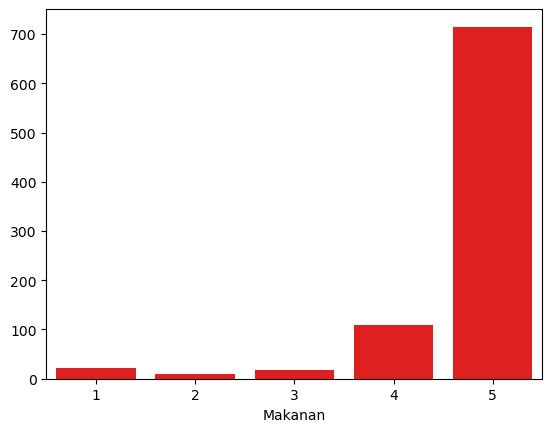

In [68]:
rating_population = makanan['Makanan'].value_counts()
sns.barplot(x=rating_population.index, y=rating_population.values, color="red")
plt.show()

In [69]:
#Rata-rata rating makanan
makanan['Makanan'].agg(['median','mean', 'std'])

median    5.000000
mean      4.705613
std       0.774702
Name: Makanan, dtype: float64

In [70]:
#modus
makanan['Makanan'].mode()

0    5
Name: Makanan, dtype: Int64

In [71]:
#mengkategorikan rating 4-5 sebagai puas, 1-2 sebagai tidak puas, dan 3 sebagai netral 
filt1 = ((makanan['Makanan'] == 4) | (makanan['Makanan'] == 5))
filt_non1 = ((makanan['Makanan'] == 1) | (makanan['Makanan'] == 2))
filt_net1 = ((makanan['Makanan'] == 3))
makanan.loc[filt1, 'Kepuasan'] = 'Puas'
makanan.loc[filt_non1, 'Kepuasan'] = 'Tidak Puas'
makanan.loc[filt_net1, 'Kepuasan'] = 'Netral'

In [72]:
#jumlah tingkat kepuasan tiap kategori
makanan['Kepuasan'].value_counts()

Kepuasan
Puas          825
Tidak Puas     30
Netral         18
Name: count, dtype: int64

In [73]:
#persentase tingkat kepuasan tiap kategori
round(makanan['Kepuasan'].value_counts(normalize=True) * 100,2)

Kepuasan
Puas          94.50
Tidak Puas     3.44
Netral         2.06
Name: proportion, dtype: float64

In [74]:
#mengubah permanen df ke Int64
df['Makanan'] = df['Makanan'].astype('Int64')

### Layanan

In [76]:
layanan = df[['Layanan']]
layanan

,Layanan
0,NaN
1,NaN
2,1.0
3,5.0
4,5.0
...,...
1553,5.0
1554,NaN
1555,NaN
1556,5.0


In [77]:
#jumlah data kosong
layanan.isnull().sum()

Layanan    373
dtype: int64

In [78]:
layanan['Layanan'].unique()

array([nan,  1.,  5.,  4.,  3.,  2.])

In [79]:
#mengubah tipe data jadi int
layanan = layanan.astype('Int64')

In [80]:
layanan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Layanan  1185 non-null   Int64
dtypes: Int64(1)
memory usage: 13.8 KB


In [81]:
total_seluruh_data = layanan.shape[0]
total_rat_layanan_kosong = layanan['Layanan'].isnull().sum()
total_rating_layanan = total_seluruh_data - total_rat_layanan_kosong

In [82]:
print("====STATISTIK DASAR KETERSEDIAAN DATA====")
print(f"Total Seluruh Baris Data         : {total_seluruh_data}")
print(f"Total Rating layanan (Ada)       : {total_rating_layanan}")
print(f"Total NaN Rating layanan (Kosong): {total_rat_layanan_kosong}\n")

# Hitung persentase berdasarkan Total Seluruh Data
pct_ada = round((total_rating_layanan / total_seluruh_data) * 100, 2)
pct_nan = round((total_rat_layanan_kosong / total_seluruh_data) * 100, 2)

print(f"Total Persentase Rating layanan (Ada)     : {pct_ada}%")
print(f"Total Persentase Rating layanan (Kosong)  : {pct_nan}%")

====STATISTIK DASAR KETERSEDIAAN DATA====
Total Seluruh Baris Data         : 1558
Total Rating layanan (Ada)       : 1185
Total NaN Rating layanan (Kosong): 373

Total Persentase Rating layanan (Ada)     : 76.06%
Total Persentase Rating layanan (Kosong)  : 23.94%


In [83]:
#statistik tiap rating count
layanan.value_counts().sort_index(ascending=False)

Layanan
5          999
4           94
3           28
2           14
1           50
Name: count, dtype: int64

In [84]:
#statistik tiap rating count by percentage
print(f"{round(layanan.value_counts(normalize=True) * 100,2).sort_index(ascending=False)}%")

Layanan
5          84.30
4           7.93
3           2.36
2           1.18
1           4.22
Name: proportion, dtype: float64%


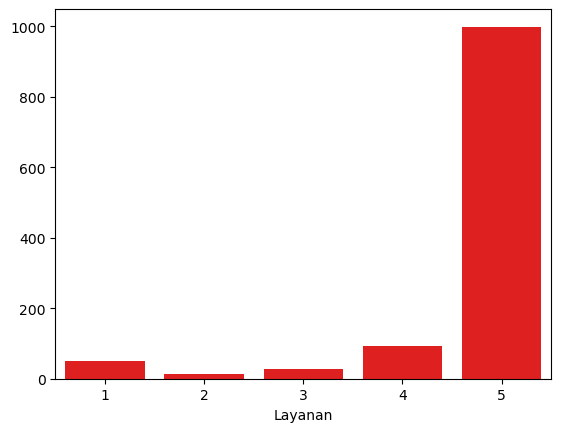

In [85]:
rating_population = layanan['Layanan'].value_counts()
sns.barplot(x=rating_population.index, y=rating_population.values, color="red")
plt.show()

In [86]:
#Rata-rata rating layanan
layanan['Layanan'].agg(['median','mean', 'std'])

median    5.000000
mean      4.669198
std       0.920086
Name: Layanan, dtype: float64

In [87]:
#modus
layanan['Layanan'].mode()

0    5
Name: Layanan, dtype: Int64

In [88]:
#mengkategorikan rating 4-5 sebagai puas, 1-2 sebagai tidak puas, dan 3 sebagai netral 
filt12 = ((layanan['Layanan'] == 4) | (layanan['Layanan'] == 5))
filt_non12 = ((layanan['Layanan'] == 1) | (layanan['Layanan'] == 2))
filt_net12 = ((layanan['Layanan'] == 3))
layanan.loc[filt12, 'Kepuasan'] = 'Puas'
layanan.loc[filt_non12, 'Kepuasan'] = 'Tidak Puas'
layanan.loc[filt_net12, 'Kepuasan'] = 'Netral'

In [89]:
#jumlah tingkat kepuasan tiap kategori
layanan['Kepuasan'].value_counts().sort_index(ascending=False)

Kepuasan
Tidak Puas      64
Puas          1093
Netral          28
Name: count, dtype: int64

In [90]:
#persentase tingkat kepuasan tiap kategori
round(layanan['Kepuasan'].value_counts(normalize=True) * 100,2).sort_index(ascending=False)

Kepuasan
Tidak Puas     5.40
Puas          92.24
Netral         2.36
Name: proportion, dtype: float64

In [91]:
#mengubah permanen df ke Int64
df['Layanan'] = df['Layanan'].astype('Int64')

### Suasana

In [93]:
suasana = df[['Suasana']]
suasana

,Suasana
0,NaN
1,NaN
2,3.0
3,4.0
4,4.0
...,...
1553,5.0
1554,NaN
1555,NaN
1556,5.0


In [94]:
suasana['Suasana'].unique()

array([nan,  3.,  4.,  5.,  1.,  2.])

In [95]:
#mengubah tipe data jadi int
suasana = suasana.astype('Int64')

In [96]:
suasana.isnull().sum()

Suasana    394
dtype: int64

In [97]:
suasana.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Suasana  1164 non-null   Int64
dtypes: Int64(1)
memory usage: 13.8 KB


In [98]:
total_seluruh_data = suasana.shape[0]
total_rat_suasana_kosong = suasana['Suasana'].isnull().sum()
total_rating_suasana = total_seluruh_data - total_rat_suasana_kosong

In [99]:
print("====STATISTIK DASAR KETERSEDIAAN DATA====")
print(f"Total Seluruh Baris Data         : {total_seluruh_data}")
print(f"Total Rating suasana (Ada)       : {total_rating_suasana}")
print(f"Total NaN Rating suasana (Kosong): {total_rat_suasana_kosong}\n")

# Hitung persentase berdasarkan Total Seluruh Data
pct_ada = round((total_rating_suasana / total_seluruh_data) * 100, 2)
pct_nan = round((total_rat_suasana_kosong / total_seluruh_data) * 100, 2)

print(f"Total Persentase Rating suasana (Ada)     : {pct_ada}%")
print(f"Total Persentase Rating suasanan (Kosong)  : {pct_nan}%")

====STATISTIK DASAR KETERSEDIAAN DATA====
Total Seluruh Baris Data         : 1558
Total Rating suasana (Ada)       : 1164
Total NaN Rating suasana (Kosong): 394

Total Persentase Rating suasana (Ada)     : 74.71%
Total Persentase Rating suasanan (Kosong)  : 25.29%


In [100]:
#statistik tiap rating count
suasana.value_counts().sort_index(ascending=False)

Suasana
5          952
4          131
3           33
2           18
1           30
Name: count, dtype: int64

In [101]:
#statistik tiap rating count by percentage
print(f"{round(suasana.value_counts(normalize=True) * 100,2).sort_index(ascending=False)}%")

Suasana
5          81.79
4          11.25
3           2.84
2           1.55
1           2.58
Name: proportion, dtype: float64%


In [102]:
#Rata-rata rating layanan
suasana['Suasana'].agg(['median','mean', 'std'])

median    5.000000
mean      4.681271
std       0.822487
Name: Suasana, dtype: float64

In [103]:
#modus
suasana['Suasana'].mode()

0    5
Name: Suasana, dtype: Int64

In [104]:
#mengkategorikan rating 4-5 sebagai puas, 1-2 sebagai tidak puas, dan 3 sebagai netral 
filt123 = ((suasana['Suasana'] == 4) | (suasana['Suasana'] == 5))
filt_non123 = ((suasana['Suasana'] == 1) | (suasana['Suasana'] == 2))
filt_net123 = ((suasana['Suasana'] == 3))
suasana.loc[filt123, 'Kepuasan'] = 'Puas'
suasana.loc[filt_non123, 'Kepuasan'] = 'Tidak Puas'
suasana.loc[filt_net123, 'Kepuasan'] = 'Netral'

In [105]:
#jumlah tingkat kepuasan tiap kategori
suasana['Kepuasan'].value_counts().sort_index(ascending=False)

Kepuasan
Tidak Puas      48
Puas          1083
Netral          33
Name: count, dtype: int64

In [106]:
#persentase tingkat kepuasan tiap kategori
round(suasana['Kepuasan'].value_counts(normalize=True) * 100,2).sort_index(ascending=False)

Kepuasan
Tidak Puas     4.12
Puas          93.04
Netral         2.84
Name: proportion, dtype: float64

In [107]:
#mengubah permanen df ke Int64
df['Suasana'] = df['Suasana'].astype('Int64')

### Tarif per orang

In [109]:
tarif_per_orang = df[['Tarif per orang']].copy()
tarif_per_orang

,Tarif per orang
0,NaN
1,NaN
2,NaN
3,Rp 25–50 rb
4,NaN
...,...
1553,NaN
1554,NaN
1555,NaN
1556,NaN


In [110]:
tarif_per_orang.isnull().sum()

Tarif per orang    1192
dtype: int64

In [111]:
#menghapus space dengan code unik yang tidak diperlukan
tarif_per_orang['Tarif per orang'] = tarif_per_orang['Tarif per orang'].str.replace('\xa0', ' ', regex=False)

urutan_tarif = [
    'Rp 1–25.000',
    'Rp 25–50 rb',
    'Rp 50–75 rb',
    'Rp 75–100 rb',
    'Rp 100–125 rb',
    'Rp 125–150 rb',
    'Rp 175–200 rb',
    'Rp 250.000+'
]

# 3. Ubah tipe data menjadi kategori ordinal yang terurut
tarif_per_orang['Tarif per orang'] = pd.Categorical(
    tarif_per_orang['Tarif per orang'], 
    categories=urutan_tarif, 
    ordered=True
)

In [112]:
tarif_per_orang['Tarif per orang'].unique()

[NaN, 'Rp 25–50 rb', 'Rp 50–75 rb', 'Rp 1–25.000', 'Rp 75–100 rb', 'Rp 100–125 rb', 'Rp 250.000+', 'Rp 125–150 rb', 'Rp 175–200 rb']
Categories (8, object): ['Rp 1–25.000' < 'Rp 25–50 rb' < 'Rp 50–75 rb' < 'Rp 75–100 rb' < 'Rp 100–125 rb' < 'Rp 125–150 rb' < 'Rp 175–200 rb' < 'Rp 250.000+']

In [113]:
total_seluruh_data = tarif_per_orang.shape[0]
total_rat_tpo_kosong = tarif_per_orang['Tarif per orang'].isnull().sum()
total_rating_tpo = total_seluruh_data - total_rat_tpo_kosong
print("====STATISTIK DASAR KETERSEDIAAN DATA====")
print(f"Total Seluruh Baris Data     : {total_seluruh_data}")
print(f"Total Rating TPO (Ada)       : {total_rating_tpo}")
print(f"Total NaN Rating TPO (Kosong): {total_rat_tpo_kosong}\n")

# Hitung persentase berdasarkan Total Seluruh Data
pct_ada = round((total_rating_tpo / total_seluruh_data) * 100, 2)
pct_nan = round((total_rat_tpo_kosong / total_seluruh_data) * 100, 2)

print(f"Total Persentase Rating TPO (Ada)     : {pct_ada}%")
print(f"Total Persentase Rating TPO (Kosong)  : {pct_nan}%")

====STATISTIK DASAR KETERSEDIAAN DATA====
Total Seluruh Baris Data     : 1558
Total Rating TPO (Ada)       : 366
Total NaN Rating TPO (Kosong): 1192

Total Persentase Rating TPO (Ada)     : 23.49%
Total Persentase Rating TPO (Kosong)  : 76.51%


In [114]:
tarif_per_orang.value_counts().sort_index()

Tarif per orang
Rp 1–25.000         46
Rp 25–50 rb        257
Rp 50–75 rb         37
Rp 75–100 rb        14
Rp 100–125 rb        7
Rp 125–150 rb        1
Rp 175–200 rb        1
Rp 250.000+          3
Name: count, dtype: int64

In [115]:
round(tarif_per_orang.value_counts(normalize=True)*100,2).sort_index()

Tarif per orang
Rp 1–25.000        12.57
Rp 25–50 rb        70.22
Rp 50–75 rb        10.11
Rp 75–100 rb        3.83
Rp 100–125 rb       1.91
Rp 125–150 rb       0.27
Rp 175–200 rb       0.27
Rp 250.000+         0.82
Name: proportion, dtype: float64

In [116]:
#mengganti dataframe data type menjadi categorical 
#menghapus space dengan code unik yang tidak diperlukan
df['Tarif per orang'] = df['Tarif per orang'].str.replace('\xa0', ' ', regex=False)

#menguah df menjadi kategorical
urutan_tarif = [
    'Rp 1–25.000',
    'Rp 25–50 rb',
    'Rp 50–75 rb',
    'Rp 75–100 rb',
    'Rp 100–125 rb',
    'Rp 125–150 rb',
    'Rp 175–200 rb',
    'Rp 250.000+'
]

# Ubah tipe data menjadi kategori ordinal yang terurut
df['Tarif per orang'] = pd.Categorical(
    df['Tarif per orang'], 
    categories=urutan_tarif, 
    ordered=True
)

### Tingkat kebisingan

In [118]:
kebisingan = df[['Tingkat kebisingan']].copy()

In [119]:
kebisingan.isnull().sum()

Tingkat kebisingan    1379
dtype: int64

In [120]:
kebisingan['Tingkat kebisingan'].unique()

array([nan, 'Tenang, mudah untuk bicara',
       'Ramai, tetapi Anda masih dapat bicara', 'Kebisingan sedang',
       'Sangat tenang', 'Sangat ramai, sulit mendengar', 'Tidak yakin'],
      dtype=object)

In [121]:
total_seluruh_data = kebisingan.shape[0]
total_rat_kosong = kebisingan['Tingkat kebisingan'].isnull().sum()
total_rating_suasana = total_seluruh_data - total_rat_kosong

print("====STATISTIK DASAR KETERSEDIAAN DATA====")
print(f"Total Seluruh Baris Data         : {total_seluruh_data}")
print(f"Total Rating TK (Ada)       : {total_rating_suasana}")
print(f"Total NaN Rating TK (Kosong): {total_rat_kosong}\n")

# Hitung persentase berdasarkan Total Seluruh Data
pct_ada = round((total_rating_suasana / total_seluruh_data) * 100, 2)
pct_nan = round((total_rat_kosong / total_seluruh_data) * 100, 2)

print(f"Total Persentase Rating TK (Ada)     : {pct_ada}%")
print(f"Total Persentase Rating TK (Kosong)  : {pct_nan}%")

====STATISTIK DASAR KETERSEDIAAN DATA====
Total Seluruh Baris Data         : 1558
Total Rating TK (Ada)       : 179
Total NaN Rating TK (Kosong): 1379

Total Persentase Rating TK (Ada)     : 11.49%
Total Persentase Rating TK (Kosong)  : 88.51%


In [122]:
# Definisikan urutan kategori dari yang paling sunyi ke paling bising
urutan_kebisingan = [
    'Sangat tenang',
    'Tenang, mudah untuk bicara',
    'Kebisingan sedang',
    'Ramai, tetapi Anda masih dapat bicara',
    'Sangat ramai, sulit mendengar',
    'Tidak yakin'
]

#  Ubah tipe data menjadi kategori ordinal yang terurut
kebisingan['Tingkat kebisingan'] = pd.Categorical(
    kebisingan['Tingkat kebisingan'], 
    categories=urutan_kebisingan, 
    ordered=True
)

In [123]:
kebisingan.value_counts().sort_index()

Tingkat kebisingan                   
Sangat tenang                            19
Tenang, mudah untuk bicara               64
Kebisingan sedang                        38
Ramai, tetapi Anda masih dapat bicara    54
Sangat ramai, sulit mendengar             3
Tidak yakin                               1
Name: count, dtype: int64

In [124]:
round(kebisingan.value_counts(normalize = True).sort_index() * 100 ,2)

Tingkat kebisingan                   
Sangat tenang                            10.61
Tenang, mudah untuk bicara               35.75
Kebisingan sedang                        21.23
Ramai, tetapi Anda masih dapat bicara    30.17
Sangat ramai, sulit mendengar             1.68
Tidak yakin                               0.56
Name: proportion, dtype: float64

In [125]:
#mengganti dataframe data type menjadi categorical 
#mengubah df menjadi kategorical
urutan_kebisingan = [
    'Sangat tenang',
    'Tenang, mudah untuk bicara',
    'Kebisingan sedang',
    'Ramai, tetapi Anda masih dapat bicara',
    'Sangat ramai, sulit mendengar',
    'Tidak yakin'
]


#  Ubah tipe data menjadi kategori ordinal yang terurut
df['Tingkat kebisingan'] = pd.Categorical(
    df['Tingkat kebisingan'], 
    categories=urutan_kebisingan, 
    ordered=True
)

# Waktu tunggu

In [127]:
waktu_tunggu = df[['Waktu tunggu']].copy()

In [128]:
waktu_tunggu.isnull().sum()

Waktu tunggu    1398
dtype: int64

In [129]:
waktu_tunggu['Waktu tunggu'].unique()

array([nan, 'Tidak menunggu', 'Maks 10 menit', '30-60 mnt', '10-30 mnt'],
      dtype=object)

In [130]:
total_seluruh_data = waktu_tunggu.shape[0]
total_rat_wt_kosong = waktu_tunggu['Waktu tunggu'].isnull().sum()
total_rating_wt = total_seluruh_data - total_rat_wt_kosong
print("====STATISTIK DASAR KETERSEDIAAN DATA====")
print(f"Total Seluruh Baris Data     : {total_seluruh_data}")
print(f"Total Rating WT (Ada)       : {total_rating_wt}")
print(f"Total NaN Rating WT (Kosong): {total_rat_wt_kosong}\n")

# Hitung persentase berdasarkan Total Seluruh Data
pct_ada = round((total_rating_wt / total_seluruh_data) * 100, 2)
pct_nan = round((total_rat_wt_kosong / total_seluruh_data) * 100, 2)

print(f"Total Persentase Rating WT (Ada)     : {pct_ada}%")
print(f"Total Persentase Rating WT (Kosong)  : {pct_nan}%")

====STATISTIK DASAR KETERSEDIAAN DATA====
Total Seluruh Baris Data     : 1558
Total Rating WT (Ada)       : 160
Total NaN Rating WT (Kosong): 1398

Total Persentase Rating WT (Ada)     : 10.27%
Total Persentase Rating WT (Kosong)  : 89.73%


In [131]:
# Definisikan urutan kategori dari yang paling sunyi ke paling bising
urutan_tunggu = [
    'Tidak menunggu',
    'Maks 10 menit',
    '10-30 mnt',
    '30-60 mnt'
    
]

#  Ubah tipe data menjadi kategori ordinal yang terurut
waktu_tunggu['Waktu tunggu'] = pd.Categorical(
     waktu_tunggu['Waktu tunggu'] , 
    categories=urutan_tunggu, 
    ordered=True
)

In [132]:
waktu_tunggu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Waktu tunggu  160 non-null    category
dtypes: category(1)
memory usage: 1.8 KB


In [133]:
waktu_tunggu.value_counts().sort_index()

Waktu tunggu  
Tidak menunggu    60
Maks 10 menit     84
10-30 mnt         15
30-60 mnt          1
Name: count, dtype: int64

In [134]:
round(waktu_tunggu.value_counts(normalize=True).sort_index() * 100, 2).sort_index()

Waktu tunggu  
Tidak menunggu    37.50
Maks 10 menit     52.50
10-30 mnt          9.38
30-60 mnt          0.62
Name: proportion, dtype: float64

In [135]:
#mengganti dataframe data type menjadi categorical 
#mengubah df menjadi kategorical
urutan_tunggu = [
    'Tidak menunggu',
    'Maks 10 menit',
    '10-30 mnt',
    '30-60 mnt'

]


#  Ubah tipe data menjadi kategori ordinal yang terurut
df['Waktu tunggu'] = pd.Categorical(
    df['Waktu tunggu'], 
    categories=urutan_tunggu, 
    ordered=True
)

### Jenis pesanan

In [137]:
jenis_pesanan = df[['Jenis pesanan']].copy()

In [138]:
jenis_pesanan.isnull().sum()

Jenis pesanan    1308
dtype: int64

In [139]:
jenis_pesanan['Jenis pesanan'].unique()

array([nan, 'Makan di tempat', 'Bawa pulang', 'Pesan antar'], dtype=object)

In [140]:
total_seluruh_data = jenis_pesanan.shape[0]
total_rat_js_kosong = jenis_pesanan['Jenis pesanan'].isnull().sum()
total_rating_js = total_seluruh_data - total_rat_js_kosong
print("====STATISTIK DASAR KETERSEDIAAN DATA====")
print(f"Total Seluruh Baris Data     : {total_seluruh_data}")
print(f"Total Rating JS (Ada)       : {total_rating_js}")
print(f"Total NaN Rating JS (Kosong): {total_rat_js_kosong}\n")

# Hitung persentase berdasarkan Total Seluruh Data
pct_ada = round((total_rating_js / total_seluruh_data) * 100, 2)
pct_nan = round((total_rat_js_kosong / total_seluruh_data) * 100, 2)

print(f"Total Persentase Rating JS (Ada)     : {pct_ada}%")
print(f"Total Persentase Rating JS (Kosong)  : {pct_nan}%")

====STATISTIK DASAR KETERSEDIAAN DATA====
Total Seluruh Baris Data     : 1558
Total Rating JS (Ada)       : 250
Total NaN Rating JS (Kosong): 1308

Total Persentase Rating JS (Ada)     : 16.05%
Total Persentase Rating JS (Kosong)  : 83.95%


In [141]:
# Definisikan urutan kategori dari yang paling sunyi ke paling bising
urutan_jenis_pesanan = [
    'Makan di tempat',
    'Bawa pulang',
    'Pesan antar'
    
]

#  Ubah tipe data menjadi kategori ordinal yang terurut
jenis_pesanan['Jenis pesanan'] = pd.Categorical(
     jenis_pesanan['Jenis pesanan'], 
    categories=urutan_jenis_pesanan, 
    ordered=True
)

In [142]:
jenis_pesanan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Jenis pesanan  250 non-null    category
dtypes: category(1)
memory usage: 1.8 KB


In [143]:
#jumlah jenis pesanan 
jenis_pesanan.value_counts()

Jenis pesanan  
Makan di tempat    204
Bawa pulang         44
Pesan antar          2
Name: count, dtype: int64

In [144]:
#persentase jenis pesanan
round(jenis_pesanan.value_counts(normalize=True) *100,2).sort_index()

Jenis pesanan  
Makan di tempat    81.6
Bawa pulang        17.6
Pesan antar         0.8
Name: proportion, dtype: float64

In [145]:
# mengubah df menjadi categorical
urutan_jenis_pesanan = [
    'Makan di tempat',
    'Bawa pulang',
    'Pesan antar'
    
]

#  Ubah tipe data menjadi kategori ordinal yang terurut
df['Jenis pesanan'] = pd.Categorical(
     df['Jenis pesanan'], 
    categories=urutan_jenis_pesanan, 
    ordered=True
)

### Jenis makanan

In [147]:
jenis_makanan = df[['Jenis makanan']].copy()

In [148]:
jenis_makanan.isnull().sum()

Jenis makanan    1372
dtype: int64

In [149]:
jenis_makanan['Jenis makanan'].unique()

array([nan, 'Makan malam', 'Lainnya', 'Makan siang', 'Sarapan siang',
       'Sarapan'], dtype=object)

In [150]:
total_seluruh_data = jenis_makanan.shape[0]
total_rat_kosong = jenis_makanan['Jenis makanan'].isnull().sum()
total_rating = total_seluruh_data - total_rat_kosong
print("====STATISTIK DASAR KETERSEDIAAN DATA====")
print(f"Total Seluruh Baris Data     : {total_seluruh_data}")
print(f"Total Rating (Ada)       : {total_rating}")
print(f"Total NaN Rating (Kosong): {total_rat_kosong}\n")

# Hitung persentase berdasarkan Total Seluruh Data
pct_ada = round((total_rating / total_seluruh_data) * 100, 2)
pct_nan = round((total_rat_kosong / total_seluruh_data) * 100, 2)

print(f"Total Persentase Rating (Ada)     : {pct_ada}%")
print(f"Total Persentase Rating (Kosong)  : {pct_nan}%")

====STATISTIK DASAR KETERSEDIAAN DATA====
Total Seluruh Baris Data     : 1558
Total Rating (Ada)       : 186
Total NaN Rating (Kosong): 1372

Total Persentase Rating (Ada)     : 11.94%
Total Persentase Rating (Kosong)  : 88.06%


In [151]:
# Definisikan urutan kategori dari yang paling sunyi ke paling bising
urutan_jenis_makan = [
    'Sarapan',
    'Sarapan siang',
    'Makan siang',
    'Makan malam',
    'Lainnya'
    
]

#  Ubah tipe data menjadi kategori ordinal yang terurut
jenis_makanan['Jenis makanan']= pd.Categorical(
     jenis_makanan['Jenis makanan'], 
    categories=urutan_jenis_makan, 
    ordered=True
)

In [152]:
jenis_makanan.value_counts().sort_index()

Jenis makanan
Sarapan          10
Sarapan siang    17
Makan siang      21
Makan malam      43
Lainnya          95
Name: count, dtype: int64

In [153]:
round(jenis_makanan.value_counts(normalize=True).sort_index() * 100, 2)

Jenis makanan
Sarapan           5.38
Sarapan siang     9.14
Makan siang      11.29
Makan malam      23.12
Lainnya          51.08
Name: proportion, dtype: float64

In [154]:
# mengubah df objek ke categorical
urutan_jenis_makan = [
    'Sarapan siang',
    'Makan siang',
    'Makan malam',
    'Lainnya'
    
]

#  Ubah tipe data menjadi kategori ordinal yang terurut
df['Jenis makanan']= pd.Categorical(
     df['Jenis makanan'], 
    categories=urutan_jenis_makan, 
    ordered=True
)

### Tempat parkir

In [156]:
tempat_parkir = df[['Tempat parkir']].copy()

In [157]:
tempat_parkir['Tempat parkir'].unique()

array([nan, 'Banyak tempat parkir', 'Tempat parkir agak sulit ditemukan',
       'Tempat parkir sulit ditemukan', 'Tidak yakin'], dtype=object)

In [158]:
tempat_parkir.isnull().sum()

Tempat parkir    1485
dtype: int64

In [159]:
total_seluruh_data = tempat_parkir.shape[0]
total_rat_kosong = tempat_parkir['Tempat parkir'].isnull().sum()
total_rating = total_seluruh_data - total_rat_kosong
print("====STATISTIK DASAR KETERSEDIAAN DATA====")
print(f"Total Seluruh Baris Data     : {total_seluruh_data}")
print(f"Total Rating (Ada)       : {total_rating}")
print(f"Total NaN Rating (Kosong): {total_rat_kosong}\n")

# Hitung persentase berdasarkan Total Seluruh Data
pct_ada = round((total_rating / total_seluruh_data) * 100, 2)
pct_nan = round((total_rat_kosong / total_seluruh_data) * 100, 2)

print(f"Total Persentase Rating (Ada)     : {pct_ada}%")
print(f"Total Persentase Rating (Kosong)  : {pct_nan}%")

====STATISTIK DASAR KETERSEDIAAN DATA====
Total Seluruh Baris Data     : 1558
Total Rating (Ada)       : 73
Total NaN Rating (Kosong): 1485

Total Persentase Rating (Ada)     : 4.69%
Total Persentase Rating (Kosong)  : 95.31%


In [160]:
# Definisikan urutan kategori dari yang paling sunyi ke paling bising
urutan_tempat_parkir = [
    'Banyak tempat parkir', 'Tempat parkir agak sulit ditemukan',
       'Tempat parkir sulit ditemukan', 'Tidak yakin'
    
]

#  Ubah tipe data menjadi kategori ordinal yang terurut
tempat_parkir['Tempat parkir']= pd.Categorical(
     tempat_parkir['Tempat parkir'], 
    categories=urutan_tempat_parkir, 
    ordered=True
)

In [161]:
tempat_parkir.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Tempat parkir  73 non-null     category
dtypes: category(1)
memory usage: 1.8 KB


In [162]:
tempat_parkir.value_counts().sort_index()

Tempat parkir                     
Banyak tempat parkir                  64
Tempat parkir agak sulit ditemukan     6
Tempat parkir sulit ditemukan          1
Tidak yakin                            2
Name: count, dtype: int64

In [163]:
round(tempat_parkir.value_counts(normalize=True).sort_index() * 100, 2)

Tempat parkir                     
Banyak tempat parkir                  87.67
Tempat parkir agak sulit ditemukan     8.22
Tempat parkir sulit ditemukan          1.37
Tidak yakin                            2.74
Name: proportion, dtype: float64

In [164]:
# mengubah df
urutan_tempat_parkir = [
    'Banyak tempat parkir', 'Tempat parkir agak sulit ditemukan',
       'Tempat parkir sulit ditemukan', 'Tidak yakin'
    
]

#  Ubah tipe data menjadi kategori ordinal yang terurut
df['Tempat parkir']= pd.Categorical(
     df['Tempat parkir'], 
    categories=urutan_tempat_parkir, 
    ordered=True
)

### Opsi tempat parkir

In [166]:
opsi_tempat_parkir = df[['Opsi tempat parkir']].copy()

In [167]:
opsi_tempat_parkir.isnull().sum()

Opsi tempat parkir    1495
dtype: int64

In [168]:
opsi_tempat_parkir['Opsi tempat parkir'].unique()

array([nan, 'Tempat parkir berbayar', 'Tempat parkir gratis',
       'Parkir di jalan berbayar',
       'Tempat parkir gratis, Parkir di jalan gratis',
       'Tempat parkir berbayar, Parkir di jalan berbayar',
       'Tempat parkir berbayar, Gedung parkir berbayar'], dtype=object)

In [169]:
total_seluruh_data = opsi_tempat_parkir.shape[0]
total_rat_kosong = opsi_tempat_parkir['Opsi tempat parkir'].isnull().sum()
total_rating = total_seluruh_data - total_rat_kosong
print("====STATISTIK DASAR KETERSEDIAAN DATA====")
print(f"Total Seluruh Baris Data     : {total_seluruh_data}")
print(f"Total Rating (Ada)       : {total_rating}")
print(f"Total NaN Rating (Kosong): {total_rat_kosong}\n")

# Hitung persentase berdasarkan Total Seluruh Data
pct_ada = round((total_rating / total_seluruh_data) * 100, 2)
pct_nan = round((total_rat_kosong / total_seluruh_data) * 100, 2)

print(f"Total Persentase Rating (Ada)     : {pct_ada}%")
print(f"Total Persentase Rating (Kosong)  : {pct_nan}%")

====STATISTIK DASAR KETERSEDIAAN DATA====
Total Seluruh Baris Data     : 1558
Total Rating (Ada)       : 63
Total NaN Rating (Kosong): 1495

Total Persentase Rating (Ada)     : 4.04%
Total Persentase Rating (Kosong)  : 95.96%


In [170]:
# Definisikan urutan kategori dari yang paling sunyi ke paling bising
urutan_opsi_tempat_parkir = [
    'Tempat parkir gratis',
    'Tempat parkir berbayar',
    'Parkir di jalan berbayar',
    'Tempat parkir gratis, Parkir di jalan gratis',
    'Tempat parkir berbayar, Parkir di jalan berbayar',
    'Tempat parkir berbayar, Gedung parkir berbayar'
    
]

#  Ubah tipe data menjadi kategori ordinal yang terurut
opsi_tempat_parkir['Opsi tempat parkir']= pd.Categorical(
    opsi_tempat_parkir['Opsi tempat parkir'], 
    categories=urutan_opsi_tempat_parkir, 
    ordered=True
)

In [171]:
opsi_tempat_parkir.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 1 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Opsi tempat parkir  63 non-null     category
dtypes: category(1)
memory usage: 1.9 KB


In [172]:
opsi_tempat_parkir.value_counts().sort_index()

Opsi tempat parkir                              
Tempat parkir gratis                                13
Tempat parkir berbayar                              43
Parkir di jalan berbayar                             4
Tempat parkir gratis, Parkir di jalan gratis         1
Tempat parkir berbayar, Parkir di jalan berbayar     1
Tempat parkir berbayar, Gedung parkir berbayar       1
Name: count, dtype: int64

In [173]:
round(opsi_tempat_parkir.value_counts(normalize=True).sort_index() * 100, 2)

Opsi tempat parkir                              
Tempat parkir gratis                                20.63
Tempat parkir berbayar                              68.25
Parkir di jalan berbayar                             6.35
Tempat parkir gratis, Parkir di jalan gratis         1.59
Tempat parkir berbayar, Parkir di jalan berbayar     1.59
Tempat parkir berbayar, Gedung parkir berbayar       1.59
Name: proportion, dtype: float64

In [174]:
# mengubah df
urutan_opsi_tempat_parkir = [
    'Tempat parkir gratis',
    'Tempat parkir berbayar',
    'Parkir di jalan berbayar',
    'Tempat parkir gratis, Parkir di jalan gratis',
    'Tempat parkir berbayar, Parkir di jalan berbayar',
    'Tempat parkir berbayar, Gedung parkir berbayar'
    
]

#  Ubah tipe data menjadi kategori ordinal yang terurut
df['Opsi tempat parkir']= pd.Categorical(
     df['Opsi tempat parkir'], 
    categories=urutan_opsi_tempat_parkir, 
    ordered=True
)

### Ukuran grup

In [176]:
ukuran_grup = df[['Ukuran grup']].copy()

In [177]:
ukuran_grup.isnull().sum()

Ukuran grup    1495
dtype: int64

In [178]:
ukuran_grup['Ukuran grup'].unique()

array([nan, '1 orang, 2 orang, 3-4 orang', '3-4 orang, 5-8 orang',
       '3-4 orang', 'Cocok untuk semua ukuran grup', '9+ orang',
       '9+ orang, Cocok untuk semua ukuran grup',
       '3-4 orang, Tidak yakin', '1 orang, 2 orang, 3-4 orang, 5-8 orang',
       '2 orang, 3-4 orang', '1 orang', '2 orang', '5-8 orang'],
      dtype=object)

In [179]:
total_seluruh_data = ukuran_grup.shape[0]
total_rat_kosong = ukuran_grup['Ukuran grup'].isnull().sum()
total_rating = total_seluruh_data - total_rat_kosong
print("====STATISTIK DASAR KETERSEDIAAN DATA====")
print(f"Total Seluruh Baris Data     : {total_seluruh_data}")
print(f"Total Rating (Ada)       : {total_rating}")
print(f"Total NaN Rating (Kosong): {total_rat_kosong}\n")

# Hitung persentase berdasarkan Total Seluruh Data
pct_ada = round((total_rating / total_seluruh_data) * 100, 2)
pct_nan = round((total_rat_kosong / total_seluruh_data) * 100, 2)

print(f"Total Persentase Rating (Ada)     : {pct_ada}%")
print(f"Total Persentase Rating (Kosong)  : {pct_nan}%")

====STATISTIK DASAR KETERSEDIAAN DATA====
Total Seluruh Baris Data     : 1558
Total Rating (Ada)       : 63
Total NaN Rating (Kosong): 1495

Total Persentase Rating (Ada)     : 4.04%
Total Persentase Rating (Kosong)  : 95.96%


In [180]:
# Definisikan urutan kategori dari yang paling sunyi ke paling bising
urutan_ukuran_grup = [
         '1 orang, 2 orang, 3-4 orang', '3-4 orang, 5-8 orang',
        '3-4 orang', 'Cocok untuk semua ukuran grup', '9+ orang',
        '9+ orang, Cocok untuk semua ukuran grup', '3-4 orang, Tidak yakin',
        '1 orang, 2 orang, 3-4 orang, 5-8 orang', '2 orang, 3-4 orang',
        '1 orang', '2 orang', '5-8 orang'
    ]
#  Ubah tipe data menjadi kategori ordinal yang terurut
ukuran_grup['Ukuran grup']= pd.Categorical(
    ukuran_grup['Ukuran grup'], 
    categories=urutan_ukuran_grup, 
    ordered=True
)

In [181]:
ukuran_grup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Ukuran grup  63 non-null     category
dtypes: category(1)
memory usage: 2.0 KB


In [182]:
ukuran_grup.value_counts().sort_index()

Ukuran grup                            
1 orang, 2 orang, 3-4 orang                 2
3-4 orang, 5-8 orang                        2
3-4 orang                                  18
Cocok untuk semua ukuran grup              23
9+ orang                                    5
9+ orang, Cocok untuk semua ukuran grup     1
3-4 orang, Tidak yakin                      1
1 orang, 2 orang, 3-4 orang, 5-8 orang      2
2 orang, 3-4 orang                          1
1 orang                                     2
2 orang                                     5
5-8 orang                                   1
Name: count, dtype: int64

In [183]:
round(ukuran_grup.value_counts(normalize=True).sort_index() * 100, 2)

Ukuran grup                            
1 orang, 2 orang, 3-4 orang                 3.17
3-4 orang, 5-8 orang                        3.17
3-4 orang                                  28.57
Cocok untuk semua ukuran grup              36.51
9+ orang                                    7.94
9+ orang, Cocok untuk semua ukuran grup     1.59
3-4 orang, Tidak yakin                      1.59
1 orang, 2 orang, 3-4 orang, 5-8 orang      3.17
2 orang, 3-4 orang                          1.59
1 orang                                     3.17
2 orang                                     7.94
5-8 orang                                   1.59
Name: proportion, dtype: float64

In [184]:
# perubahan pada df
urutan_ukuran_grup = [
         '1 orang, 2 orang, 3-4 orang', '3-4 orang, 5-8 orang',
        '3-4 orang', 'Cocok untuk semua ukuran grup', '9+ orang',
        '9+ orang, Cocok untuk semua ukuran grup', '3-4 orang, Tidak yakin',
        '1 orang, 2 orang, 3-4 orang, 5-8 orang', '2 orang, 3-4 orang',
        '1 orang', '2 orang', '5-8 orang'
    ]
#  Ubah tipe data menjadi kategori ordinal yang terurut
df['Ukuran grup']= pd.Categorical(
    df['Ukuran grup'], 
    categories=urutan_ukuran_grup, 
    ordered=True
)

### Cafe

In [186]:
df['cafe'].isnull().sum()

0

In [187]:
df['cafe'].unique()

array(['PM Noor Samarinda', 'M Yamin', 'Sebatik', 'Merak Square',
       'Bung Tomo'], dtype=object)

In [188]:
df['cafe'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1558 entries, 0 to 1557
Series name: cafe
Non-Null Count  Dtype 
--------------  ----- 
1558 non-null   object
dtypes: object(1)
memory usage: 12.3+ KB


In [189]:
# perubahan pada df
cabang_cafe = ["PM Noor Samarinda", "M Yamin", "Sebatik", "Merak Square", "Bung Tomo"]
#  Ubah tipe data menjadi kategori ordinal yang terurut
df['cafe']= pd.Categorical(
    df['cafe'], 
    categories=cabang_cafe, 
    ordered=True
)

In [190]:
df['cafe'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1558 entries, 0 to 1557
Series name: cafe
Non-Null Count  Dtype   
--------------  -----   
1558 non-null   category
dtypes: category(1)
memory usage: 1.9 KB


In [191]:
df['cafe'].unique()

['PM Noor Samarinda', 'M Yamin', 'Sebatik', 'Merak Square', 'Bung Tomo']
Categories (5, object): ['PM Noor Samarinda' < 'M Yamin' < 'Sebatik' < 'Merak Square' < 'Bung Tomo']

In [192]:
df['cafe'].isnull().sum()

0

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   nama_reviewer               1558 non-null   object        
 1   rating                      1558 non-null   int64         
 2   waktu_relatif               1558 non-null   object        
 3   review                      902 non-null    object        
 4   Makanan                     873 non-null    Int64         
 5   Layanan                     1185 non-null   Int64         
 6   Suasana                     1164 non-null   Int64         
 7   Tarif per orang             366 non-null    category      
 8   Tingkat kebisingan          179 non-null    category      
 9   Waktu tunggu                160 non-null    category      
 10  Jenis pesanan               250 non-null    category      
 11  Jenis makanan               176 non-null    category    

### Tingkat Kepuasan

In [195]:
df['Tingkat Kepuasan'].isnull().sum()

0

In [196]:
df['Tingkat Kepuasan'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1558 entries, 0 to 1557
Series name: Tingkat Kepuasan
Non-Null Count  Dtype 
--------------  ----- 
1558 non-null   object
dtypes: object(1)
memory usage: 12.3+ KB


In [197]:
#  Definisikan urutan kepuasan dari terendah ke tertinggi
urutan_kepuasan = ['Tidak Puas', 'Netral', 'Puas']

# Ubah tipe data menjadi kategori ordinal yang terurut
df['Tingkat Kepuasan'] = pd.Categorical(
    df['Tingkat Kepuasan'], 
    categories=urutan_kepuasan, 
    ordered=True
)

In [198]:
df['Tingkat Kepuasan'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1558 entries, 0 to 1557
Series name: Tingkat Kepuasan
Non-Null Count  Dtype   
--------------  -----   
1558 non-null   category
dtypes: category(1)
memory usage: 1.8 KB


In [199]:
df['Tingkat Kepuasan'].unique()

['Puas', 'Tidak Puas', 'Netral']
Categories (3, object): ['Tidak Puas' < 'Netral' < 'Puas']

### KOLOM YANG AKAN DIHAPUS

In [201]:
# Cek jumlah data yang terisi (bukan NaN) untuk semua kolom baru
kolom_baru = [
    'Jenis tempat duduk', 'Pilihan menu vegetarian', 'Aksesibilitas kursi roda', 
    'Kesesuaian untuk anak-anak', 'Rekomendasi hidangan', 'Reservasi', 
    'Parkir', 'Penawaran spesial', 'Acara spesial', 'Batasan diet'
]

df[kolom_baru].notna().sum()

Jenis tempat duduk            19
Pilihan menu vegetarian        4
Aksesibilitas kursi roda       5
Kesesuaian untuk anak-anak     4
Rekomendasi hidangan           0
Reservasi                     16
Parkir                         9
Penawaran spesial              1
Acara spesial                 26
Batasan diet                   3
dtype: int64

In [202]:
#  kolom yang datanya di bawah 30 (tidak valid secara statistik)
kolom_di_drop = [
    'Jenis tempat duduk', 'Pilihan menu vegetarian', 'Aksesibilitas kursi roda', 
    'Kesesuaian untuk anak-anak', 'Rekomendasi hidangan', 'Reservasi', 
    'Parkir', 'Penawaran spesial', 'Acara spesial', 'Batasan diet'
]

# Hapus kolom dari DataFrame utama
df = df.drop(columns=kolom_di_drop)

In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   nama_reviewer       1558 non-null   object        
 1   rating              1558 non-null   int64         
 2   waktu_relatif       1558 non-null   object        
 3   review              902 non-null    object        
 4   Makanan             873 non-null    Int64         
 5   Layanan             1185 non-null   Int64         
 6   Suasana             1164 non-null   Int64         
 7   Tarif per orang     366 non-null    category      
 8   Tingkat kebisingan  179 non-null    category      
 9   Waktu tunggu        160 non-null    category      
 10  Jenis pesanan       250 non-null    category      
 11  Jenis makanan       176 non-null    category      
 12  Tempat parkir       73 non-null     category      
 13  Opsi tempat parkir  63 non-null     category    

## Menyimpan data bersih ke parquet

In [205]:
df.to_parquet('data_review_full_bersih.parquet', index=False)

In [206]:
df_check = pd.read_parquet('data_review_full_bersih.parquet')
df_check.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1558 entries, 0 to 1557
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   nama_reviewer       1558 non-null   object        
 1   rating              1558 non-null   int64         
 2   waktu_relatif       1558 non-null   object        
 3   review              902 non-null    object        
 4   Makanan             873 non-null    Int64         
 5   Layanan             1185 non-null   Int64         
 6   Suasana             1164 non-null   Int64         
 7   Tarif per orang     366 non-null    category      
 8   Tingkat kebisingan  179 non-null    category      
 9   Waktu tunggu        160 non-null    category      
 10  Jenis pesanan       250 non-null    category      
 11  Jenis makanan       176 non-null    category      
 12  Tempat parkir       73 non-null     category      
 13  Opsi tempat parkir  63 non-null     category    

# Pembersihan data bisnis 

In [71]:
import pandas as pd
df = pd.read_excel('file/bisnis-profile-tomoro-samarinda.xlsx')
df

,nama,rating_review,alamat,nomor_hp,instagram
0,TOMORO COFFEE - PM Noor Samarinda,"4,6 bintang 234 Ulasan","Jl. PM. Noor, Sempaja Sel., Kec. Samarinda Utara, Kota Samarinda, Kalimantan Timur 75119",NaN,NaN
1,TOMORO COFFEE M YAMIN,"4,5 bintang 190 Ulasan","l. M. Yamin No.8, Gn. Kelua, Kec. Samarinda Ulu, Kota Samarinda, Kalimantan Timur 75121",858-3311-6666,NaN
2,TOMORO COFFEE - SEBATIK SAMARINDA,"4,7 bintang 335 Ulasan","F5X2+FWW, Jl. Pulau Sebatik, Pelabuhan, Kec. Samarinda Kota, Kota Samarinda, Kalimantan Timur 75242",0822-8111-2323,https://www.instagram.com/tommunitysebatik
3,TOMORO COFFEE - Merak Square Samarinda,"4,7 bintang 611 Ulasan","Komplek Merak Square, Jl. Hasan Basri No. 53, Temindung Permai, Sungai Pinang, Samarinda City, East Kalimantan 75119, Temindung Permai, Kec. Sungai Pinang, Kota Samarinda, Kalimantan Timur 75117",0822-8111-2323,https://www.instagram.com/tommunitymeraksquare?igsh=bmh3YTBqbWlmbmI4
4,TOMORO COFFEE BUNG TOMO,"4,6 bintang 188 Ulasan","Jl. Bung Tomo No.68e, Sungai Keledang, Kec. Samarinda Seberang, Kota Samarinda, Kalimantan Timur 75131",NaN,NaN


In [73]:
#banyak baris dan kolom
df.shape

(5, 5)

In [75]:
#nama kolom
df.columns

Index(['nama', 'rating_review', 'alamat', 'nomor_hp', 'instagram'], dtype='object')

### Nama

In [78]:
nama = df[['nama']].copy()

In [80]:
#mengganti nama cafe dengan format yang lebih bagus, langsung diubah saja karena sedikit data saja
df.loc[1, "nama"] = 'TOMORO COFFEE - M Yamin'
df.loc[4, "nama"] = 'TOMORO COFFEE - Bung Tomo'
#mengubah data type objek menjadi string
df['nama'] = df['nama'].astype('string')
#membuat semua karakter menjadi uppercase
df['nama'] = df.nama.str.upper()

In [82]:
df

,nama,rating_review,alamat,nomor_hp,instagram
0,TOMORO COFFEE - PM NOOR SAMARINDA,"4,6 bintang 234 Ulasan","Jl. PM. Noor, Sempaja Sel., Kec. Samarinda Utara, Kota Samarinda, Kalimantan Timur 75119",NaN,NaN
1,TOMORO COFFEE - M YAMIN,"4,5 bintang 190 Ulasan","l. M. Yamin No.8, Gn. Kelua, Kec. Samarinda Ulu, Kota Samarinda, Kalimantan Timur 75121",858-3311-6666,NaN
2,TOMORO COFFEE - SEBATIK SAMARINDA,"4,7 bintang 335 Ulasan","F5X2+FWW, Jl. Pulau Sebatik, Pelabuhan, Kec. Samarinda Kota, Kota Samarinda, Kalimantan Timur 75242",0822-8111-2323,https://www.instagram.com/tommunitysebatik
3,TOMORO COFFEE - MERAK SQUARE SAMARINDA,"4,7 bintang 611 Ulasan","Komplek Merak Square, Jl. Hasan Basri No. 53, Temindung Permai, Sungai Pinang, Samarinda City, East Kalimantan 75119, Temindung Permai, Kec. Sungai Pinang, Kota Samarinda, Kalimantan Timur 75117",0822-8111-2323,https://www.instagram.com/tommunitymeraksquare?igsh=bmh3YTBqbWlmbmI4
4,TOMORO COFFEE - BUNG TOMO,"4,6 bintang 188 Ulasan","Jl. Bung Tomo No.68e, Sungai Keledang, Kec. Samarinda Seberang, Kota Samarinda, Kalimantan Timur 75131",NaN,NaN


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   nama           5 non-null      string
 1   rating_review  5 non-null      object
 2   alamat         5 non-null      object
 3   nomor_hp       3 non-null      object
 4   instagram      2 non-null      object
dtypes: object(4), string(1)
memory usage: 332.0+ bytes


### rating_review

In [87]:
rating_review = df[['rating_review']].copy()

In [89]:
rating_review['rating_review'] = rating_review['rating_review'].astype('string')

In [91]:
rating_review

,rating_review
0,"4,6 bintang 234 Ulasan"
1,"4,5 bintang 190 Ulasan"
2,"4,7 bintang 335 Ulasan"
3,"4,7 bintang 611 Ulasan"
4,"4,6 bintang 188 Ulasan"


In [93]:
#mengambil angka pertama dengan regex dan membuat kolom
import re
hasil = rating_review['rating_review'].str.replace(r'\D{1,2}', '', regex=True).str[:2]
bintang = hasil.astype(float) / 10
bintang

0    4.6
1    4.5
2    4.7
3    4.7
4    4.6
Name: rating_review, dtype: float64

In [95]:
hs = rating_review['rating_review'].str.extract(r'bintang\s+(\d+)')
hasil_ulasan = hs.astype(int)
hasil_ulasan

,0
0,234
1,190
2,335
3,611
4,188


In [97]:
#membuat 2 kolom baru
df['bintang'] = bintang
df['total_ulasan'] = hasil_ulasan

df = df.drop(columns='rating_review')
df

,nama,alamat,nomor_hp,instagram,bintang,total_ulasan
0,TOMORO COFFEE - PM NOOR SAMARINDA,"Jl. PM. Noor, Sempaja Sel., Kec. Samarinda Utara, Kota Samarinda, Kalimantan Timur 75119",NaN,NaN,4.6,234
1,TOMORO COFFEE - M YAMIN,"l. M. Yamin No.8, Gn. Kelua, Kec. Samarinda Ulu, Kota Samarinda, Kalimantan Timur 75121",858-3311-6666,NaN,4.5,190
2,TOMORO COFFEE - SEBATIK SAMARINDA,"F5X2+FWW, Jl. Pulau Sebatik, Pelabuhan, Kec. Samarinda Kota, Kota Samarinda, Kalimantan Timur 75242",0822-8111-2323,https://www.instagram.com/tommunitysebatik,4.7,335
3,TOMORO COFFEE - MERAK SQUARE SAMARINDA,"Komplek Merak Square, Jl. Hasan Basri No. 53, Temindung Permai, Sungai Pinang, Samarinda City, East Kalimantan 75119, Temindung Permai, Kec. Sungai Pinang, Kota Samarinda, Kalimantan Timur 75117",0822-8111-2323,https://www.instagram.com/tommunitymeraksquare?igsh=bmh3YTBqbWlmbmI4,4.7,611
4,TOMORO COFFEE - BUNG TOMO,"Jl. Bung Tomo No.68e, Sungai Keledang, Kec. Samarinda Seberang, Kota Samarinda, Kalimantan Timur 75131",NaN,NaN,4.6,188


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   nama          5 non-null      string 
 1   alamat        5 non-null      object 
 2   nomor_hp      3 non-null      object 
 3   instagram     2 non-null      object 
 4   bintang       5 non-null      float64
 5   total_ulasan  5 non-null      int32  
dtypes: float64(1), int32(1), object(3), string(1)
memory usage: 352.0+ bytes


### Alamat

In [102]:
alamat = df[['alamat']].copy()

In [104]:
pd.set_option('display.max_colwidth', None)
alamat

,alamat
0,"Jl. PM. Noor, Sempaja Sel., Kec. Samarinda Utara, Kota Samarinda, Kalimantan Timur 75119"
1,"l. M. Yamin No.8, Gn. Kelua, Kec. Samarinda Ulu, Kota Samarinda, Kalimantan Timur 75121"
2,"F5X2+FWW, Jl. Pulau Sebatik, Pelabuhan, Kec. Samarinda Kota, Kota Samarinda, Kalimantan Timur 75242"
3,"Komplek Merak Square, Jl. Hasan Basri No. 53, Temindung Permai, Sungai Pinang, Samarinda City, East Kalimantan 75119, Temindung Permai, Kec. Sungai Pinang, Kota Samarinda, Kalimantan Timur 75117"
4,"Jl. Bung Tomo No.68e, Sungai Keledang, Kec. Samarinda Seberang, Kota Samarinda, Kalimantan Timur 75131"


In [106]:
alamat.loc[0, 'Kecamatan'] = 'Samarinda Utara'
alamat.loc[1, 'Kecamatan'] = 'Samarinda Ulu'
alamat.loc[2, 'Kecamatan'] = 'Samarinda Kota'
alamat.loc[3, 'Kecamatan'] = 'Sungai Pinang'
alamat.loc[4, 'Kecamatan'] = 'Samarinda Seberang'

In [108]:
alamat

,alamat,Kecamatan
0,"Jl. PM. Noor, Sempaja Sel., Kec. Samarinda Utara, Kota Samarinda, Kalimantan Timur 75119",Samarinda Utara
1,"l. M. Yamin No.8, Gn. Kelua, Kec. Samarinda Ulu, Kota Samarinda, Kalimantan Timur 75121",Samarinda Ulu
2,"F5X2+FWW, Jl. Pulau Sebatik, Pelabuhan, Kec. Samarinda Kota, Kota Samarinda, Kalimantan Timur 75242",Samarinda Kota
3,"Komplek Merak Square, Jl. Hasan Basri No. 53, Temindung Permai, Sungai Pinang, Samarinda City, East Kalimantan 75119, Temindung Permai, Kec. Sungai Pinang, Kota Samarinda, Kalimantan Timur 75117",Sungai Pinang
4,"Jl. Bung Tomo No.68e, Sungai Keledang, Kec. Samarinda Seberang, Kota Samarinda, Kalimantan Timur 75131",Samarinda Seberang


In [110]:
# menambahkan kolom pada df kecamatan
df.loc[0, 'Kecamatan'] = 'Samarinda Utara'
df.loc[1, 'Kecamatan'] = 'Samarinda Ulu'
df.loc[2, 'Kecamatan'] = 'Samarinda Kota'
df.loc[3, 'Kecamatan'] = 'Sungai Pinang'
df.loc[4, 'Kecamatan'] = 'Samarinda Seberang'

In [112]:
df['Kecamatan'] = df['Kecamatan'].astype("string")

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   nama          5 non-null      string 
 1   alamat        5 non-null      object 
 2   nomor_hp      3 non-null      object 
 3   instagram     2 non-null      object 
 4   bintang       5 non-null      float64
 5   total_ulasan  5 non-null      int32  
 6   Kecamatan     5 non-null      string 
dtypes: float64(1), int32(1), object(3), string(2)
memory usage: 392.0+ bytes


In [116]:
df

,nama,alamat,nomor_hp,instagram,bintang,total_ulasan,Kecamatan
0,TOMORO COFFEE - PM NOOR SAMARINDA,"Jl. PM. Noor, Sempaja Sel., Kec. Samarinda Utara, Kota Samarinda, Kalimantan Timur 75119",NaN,NaN,4.6,234,Samarinda Utara
1,TOMORO COFFEE - M YAMIN,"l. M. Yamin No.8, Gn. Kelua, Kec. Samarinda Ulu, Kota Samarinda, Kalimantan Timur 75121",858-3311-6666,NaN,4.5,190,Samarinda Ulu
2,TOMORO COFFEE - SEBATIK SAMARINDA,"F5X2+FWW, Jl. Pulau Sebatik, Pelabuhan, Kec. Samarinda Kota, Kota Samarinda, Kalimantan Timur 75242",0822-8111-2323,https://www.instagram.com/tommunitysebatik,4.7,335,Samarinda Kota
3,TOMORO COFFEE - MERAK SQUARE SAMARINDA,"Komplek Merak Square, Jl. Hasan Basri No. 53, Temindung Permai, Sungai Pinang, Samarinda City, East Kalimantan 75119, Temindung Permai, Kec. Sungai Pinang, Kota Samarinda, Kalimantan Timur 75117",0822-8111-2323,https://www.instagram.com/tommunitymeraksquare?igsh=bmh3YTBqbWlmbmI4,4.7,611,Sungai Pinang
4,TOMORO COFFEE - BUNG TOMO,"Jl. Bung Tomo No.68e, Sungai Keledang, Kec. Samarinda Seberang, Kota Samarinda, Kalimantan Timur 75131",NaN,NaN,4.6,188,Samarinda Seberang


## menyimpan data 

In [119]:
df.to_parquet('data_bisnis_full_bersih.parquet', index=False)

In [121]:
df_check = pd.read_parquet('data_bisnis_full_bersih.parquet')
df_check.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   nama          5 non-null      string 
 1   alamat        5 non-null      object 
 2   nomor_hp      3 non-null      object 
 3   instagram     2 non-null      object 
 4   bintang       5 non-null      float64
 5   total_ulasan  5 non-null      int32  
 6   Kecamatan     5 non-null      string 
dtypes: float64(1), int32(1), object(3), string(2)
memory usage: 392.0+ bytes


# PROSES SELESAI 